<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Input_Engineering_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pkgs <- c("caret", "Boruta")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘RcppEigen’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’, ‘ranger’




In [5]:
library (caret)
library (Boruta)

credit_data = read.csv ("credit.csv", stringsAsFactors = TRUE)

#### Parameter Tuning using the Train Function ####

*   We are going to use 5-fold cross-validation to select
*    The best tuning parameter (hyperparameter?)


In [6]:
ctrl = trainControl (method = "cv",
                     number = 5,
                     savePred = T,
                     classProb = T)
grid = expand.grid (k = c(1:50))
knn.tuning = train(class~., data = credit_data, method = "knn",
                   trControl=ctrl, tuneGrid=grid)
best.k.train = knn.tuning$bestTune
as.numeric(best.k.train)
knn.tuning$results[as.numeric(best.k.train),2]

[1] 37

[1] 0.705

trainControl() specifies the training parameters:


*   Number = sets the number of folds for cv
*   savePred = T (True): Save the predictions for each resample
*   classProb = T (True): this saves class probabilities, which is useful for classification models.

expand.grid () creates a data frame which defines the range of k values from 1 to 50

train () performs the model training and hyperparameter selection.

knn.tuning$results[as.numeric(best.k.train),2]
 *   This means go to knn tuning result. Then, select the row corresponding to the best.k.train value and retrieve the value from the second column (accuracy)





---
We get a 5-fold cross-validation estimate of the error for the optimal parameter value. Any problems?

---


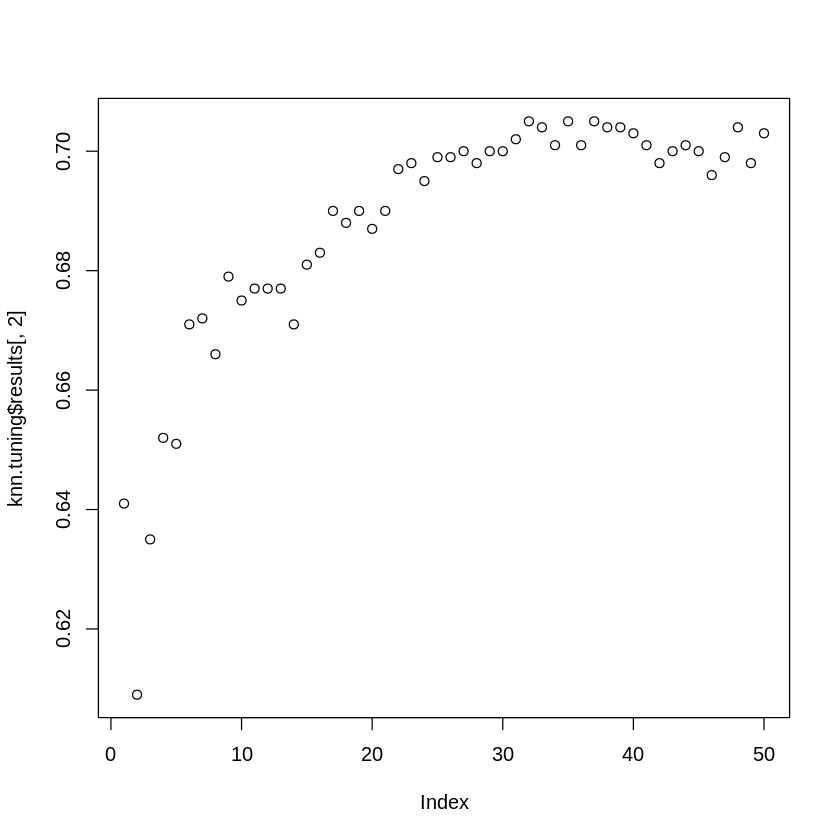

In [7]:
plot (knn.tuning$results[,2])

If we pick k with lower number, it will be too close to the data. But as k get larger, it will predict the majority class (70%)
*   The up and down after they keeps predict the majority is just the variability of the estimates (random noises)

*   The more complex our model, the more errors we will introduce if we don't pay attention to this.

---
#### Estimating Accuracy using Cross-Validation ####

*    You want to incorporate the whole learning process into the cross-validation loop. Did we do that above?


 Create folds
 *   Using split(), instead of train(), so we can have a complete control of the situation
 *   train() and the tuning is now inside the cv loop

[1] 0.698

[1] 46 22 45 28 24

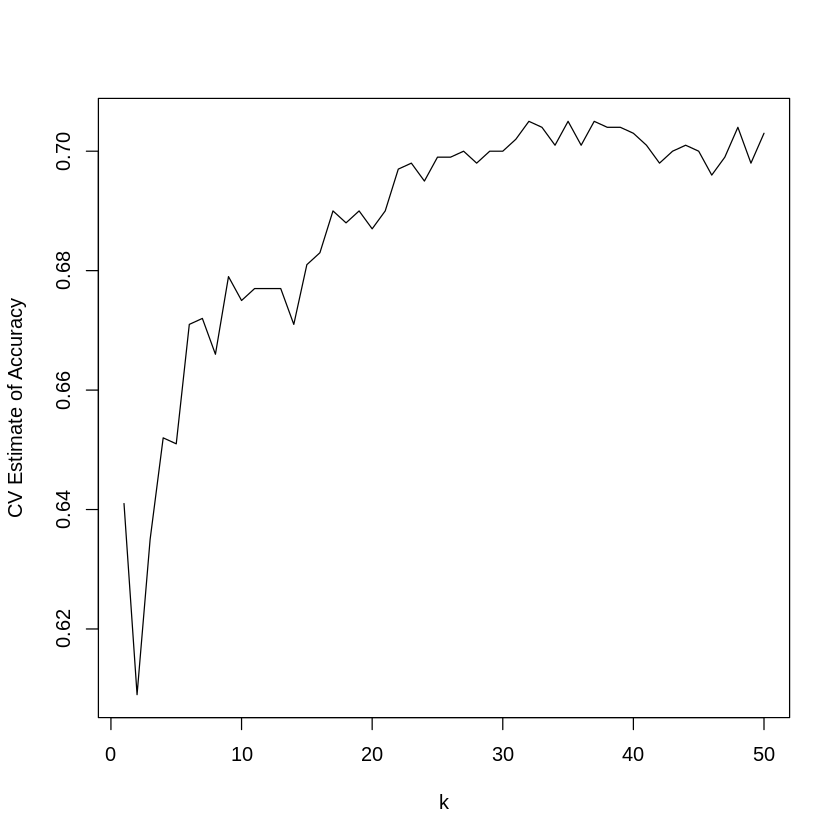

In [8]:
set.seed(1234)
folds = split(sample(nrow(credit_data), nrow(credit_data),replace=FALSE),
                                             as.factor(1:5))

best.k = NULL
fold.accuracy.estimate = NULL
for(f in 1:5){
  trainingData = credit_data[-folds[[f]],]
  testData = credit_data[folds[[f]],]
  model_knn5 = train(class~., data=trainingData, method="knn",
                     trControl=ctrl, tuneGrid=grid)

  best.k[f] = as.numeric(model_knn5$bestTune)

  fold.accuracy.estimate[f] = (table(predict(model_knn5,testData),
                                      testData$class)[1,1]
                               +table(predict(model_knn5,testData),
                               testData$class)[2,2]
  )/length(testData$class)
}
mean(fold.accuracy.estimate)

best.k

plot(knn.tuning$results[,2], type="l", xlab="k", ylab="CV Estimate of Accuracy")



folds = split(sample(nrow(credit_data), nrow(credit_data),replace=FALSE),as.factor(1:5))

*   This creates 5 distinct folds for the outer cv loop. It first shuffles the row indices in credit_data and then splits these shuffled indices into 5 equally sized groups. Each group will serve as a test set in one iteration.
*   sample (nrow of dataset, the size of the sample to be drawn, replaced the sample back or not [once the item is sampled, it cannot be sampled again, ensure data points only appears exactly])

trainingData = credit_data[-folds[[f]],]
 *   for each f, select all rows in credit_data, except those in the current fold

 testData = credit_data[folds[[f]],]
 *   create test dataset from the current fold data

 Plot
 *   type = "1" : Line plot
 *   type = "p" : points
 *   type = "b" : both points and lines



#### Attribute Selection + Tuning ####

*    The importance of correct cross-validation becomes more important now that we have more components in our learning process.

*   Let's do attribute selection, then tuning ...

 Create a boruta object

In [9]:
boruta_credit = Boruta(class ~ .,
                       data = credit_data,
                       doTrace = 2,
                       maxRuns = 25)
boruta_credit$finalDecision

 1. run of importance source...

 2. run of importance source...

 3. run of importance source...

 4. run of importance source...

 5. run of importance source...

 6. run of importance source...

 7. run of importance source...

 8. run of importance source...

 9. run of importance source...

 10. run of importance source...

 11. run of importance source...

After 11 iterations, +15 secs: 

 confirmed 7 attributes: age, checking_status, credit_amount, credit_history, duration and 2 more;

 rejected 2 attributes: num_dependents, own_telephone;

 still have 11 attributes left.


 12. run of importance source...

 13. run of importance source...

 14. run of importance source...

 15. run of importance source...

After 15 iterations, +20 secs: 

 confirmed 1 attribute: installment_commitment;

 still have 10 attributes left.


 16. run of importance source...

 17. run of importance source...

 18. run of importance source...

 19. run of importance source...

After 19 iterations, +26

checking_status               duration         credit_history 
             Confirmed              Confirmed              Confirmed 
               purpose          credit_amount         savings_status 
             Confirmed              Confirmed              Confirmed 
            employment installment_commitment        personal_status 
             Tentative              Confirmed              Tentative 
         other_parties        residence_since     property_magnitude 
             Confirmed              Tentative              Tentative 
                   age    other_payment_plans                housing 
             Confirmed              Confirmed              Tentative 
      existing_credits                    job         num_dependents 
             Tentative              Tentative               Rejected 
         own_telephone         foreign_worker 
              Rejected              Tentative 
Levels: Tentative Confirmed Rejected

Boruta() : selection wrapper algorithm built around the Random Forest algorithm.
*   doTrace > 0: tell the algorithm to print messages to the console about its progress.
    *   0 : no messages
    *   1 : print a single line for each run
    *   2: details)

---
Automatically get the selected attributes
---

In [10]:
credit_data_2 = credit_data[,c(getSelectedAttributes(boruta_credit),"class")]

Now we tune using the train() function in caret, and evaluate the results using 5-fold cross-validation


In [11]:
ctrl = trainControl(method = "cv",
                    number = 5,
                    savePred = T,
                    classProb = T)
grid = expand.grid(k=c(1:50))
knn.tuning = train(class~., data = credit_data_2, method = "knn",
                   trControl=ctrl, tuneGrid=grid)
best.k.train = knn.tuning$bestTune
as.numeric(best.k.train)
knn.tuning$results[as.numeric(best.k.train),2]

[1] 46

[1] 0.711

Are you happy with this cross-validation estimate?
 *   No, because we didn't evaluate the product of combining attribute selection + tuning + picking the best k

 *   The correct way is to put everything that we just did and put it in another evaluation loop.

 *   However, if we have a small dataset, it's better if we use resampling or bootstraps.

*   Can also custom train () so it will do this before tuning

---
Correct approach to get a cross-validation estimate of the error when the training involves both attribute selection and tuning.

*   Split the original training data into folds
---

In [12]:
set.seed(1234)
folds = split(sample(nrow(credit_data),
                     nrow(credit_data),replace=FALSE),
              as.factor(1:5))

best.k = NULL
fold.accuracy.estimate = NULL
for(f in 1:5){
  trainingData = credit_data[-folds[[f]],]
  testData = credit_data[folds[[f]],]

  # Attribute selection inside the loop
  boruta_credit = Boruta(class ~ .,
                         data = trainingData,
                         doTrace = 2,
                         maxRuns = 25)
  boruta_credit$finalDecision
  trainingData_2 = trainingData[,c(getSelectedAttributes(boruta_credit),"class")]

  # Tuning inside the loop
  model_knn5 = train(class~., data=trainingData_2, method="knn",
                     trControl=ctrl, tuneGrid=grid)
  best.k[f] = as.numeric(model_knn5$bestTune)

  # Evaluate the error on the independent test fold
  fold.accuracy.estimate[f] = (table(predict(model_knn5,testData),testData$class)[1,1]
                               +table(predict(model_knn5,testData),testData$class)[2,2]
  )/length(testData$class)
}
mean(fold.accuracy.estimate)

 1. run of importance source...

 2. run of importance source...

 3. run of importance source...

 4. run of importance source...

 5. run of importance source...

 6. run of importance source...

 7. run of importance source...

 8. run of importance source...

 9. run of importance source...

 10. run of importance source...

 11. run of importance source...

After 11 iterations, +12 secs: 

 confirmed 6 attributes: age, checking_status, credit_amount, credit_history, duration and 1 more;

 rejected 2 attributes: job, own_telephone;

 still have 12 attributes left.


 12. run of importance source...

 13. run of importance source...

 14. run of importance source...

 15. run of importance source...

After 15 iterations, +15 secs: 

 rejected 1 attribute: foreign_worker;

 still have 11 attributes left.


 16. run of importance source...

 17. run of importance source...

 18. run of importance source...

 19. run of importance source...

After 19 iterations, +19 secs: 

 rejected 1

[1] 0.699

What else should go inside your cross-validation loop?

1. First resample the data

I'm going to do a quick biased resampling. You should try other alternatives (just oversampling, SMOTE)

In [13]:
p = ifelse(credit_data$class=="good",0.2,0.8)
resampled = sample(nrow(credit_data),
                   nrow(credit_data),
                   replace=TRUE,
                   prob=p)
credit_data_3 = credit_data[resampled,]


If class == "good", the corresponding probability is 0.2. If not, it is 0.8.

In [15]:
summary (credit_data_3$class)

bad good 
 641  359

2. Second, do attribute selection
*   create new dataset based on those selected attributes.

In [14]:
boruta_credit = Boruta(class ~ .,
                       data = credit_data_3,
                       doTrace = 2,
                       maxRuns = 25)
credit_data_2 = credit_data_3[,c(getSelectedAttributes(boruta_credit),"class")]

 1. run of importance source...

 2. run of importance source...

 3. run of importance source...

 4. run of importance source...

 5. run of importance source...

 6. run of importance source...

 7. run of importance source...

 8. run of importance source...

 9. run of importance source...

 10. run of importance source...

 11. run of importance source...

After 11 iterations, +16 secs: 

 confirmed 20 attributes: age, checking_status, credit_amount, credit_history, duration and 15 more;

 no more attributes left.




3. Tune the knn

In [16]:
ctrl = trainControl(method = "cv",
                    number = 5,
                    savePred = T,
                    classProb = T)
grid = expand.grid(k=c(1:50))
knn.tuning = train(class~., data = credit_data_2, method = "knn",
                   trControl=ctrl, tuneGrid=grid)
best.k.train = knn.tuning$bestTune
as.numeric(best.k.train)
knn.tuning$results[as.numeric(best.k.train),2]

[1] 1

[1] 0.8479836

Best k =1 now, very diffrent conclusion from before.
*   Now the same data points are in the training and test data folds

And now for the correct approach ...

Split the original training data into folds

In [18]:
set.seed(1234)
folds = split(sample(nrow(credit_data),
                     nrow(credit_data),replace=FALSE),
              as.factor(1:5))

best.k = NULL
fold.accuracy.estimate = NULL
for(f in 1:5){
  trainingData = credit_data[-folds[[f]],]
  testData = credit_data[folds[[f]],]

  # 1. Resampling inside the loop
  p = ifelse(trainingData$class=="good",0.2,0.8)
  resampled = sample(nrow(trainingData),
                     nrow(trainingData),
                     replace=TRUE,
                     prob=p)
  trainingData_3 = trainingData[resampled,]

  # 2. Attribute selection inside the loop
  boruta_credit = Boruta(class ~ .,
                         data = trainingData_3,
                         doTrace = 2,
                         maxRuns = 25)
  boruta_credit$finalDecision
  trainingData_2 = trainingData[,c(getSelectedAttributes(boruta_credit),"class")]

  # 3. Tuning inside the loop
  model_knn5 = train(class~., data=trainingData_2, method="knn",
                     trControl=ctrl, tuneGrid=grid)
  best.k[f] = as.numeric(model_knn5$bestTune)

  # Evaluate the error on the independent test fold
  fold.accuracy.estimate[f] = (table(predict(model_knn5,testData),testData$class)[1,1]
                               +table(predict(model_knn5,testData),testData$class)[2,2]
  )/length(testData$class)
}
mean(fold.accuracy.estimate)


 1. run of importance source...

 2. run of importance source...

 3. run of importance source...

 4. run of importance source...

 5. run of importance source...

 6. run of importance source...

 7. run of importance source...

 8. run of importance source...

 9. run of importance source...

 10. run of importance source...

 11. run of importance source...

After 11 iterations, +11 secs: 

 confirmed 19 attributes: age, checking_status, credit_amount, credit_history, duration and 14 more;

 still have 1 attribute left.


 12. run of importance source...

 13. run of importance source...

 14. run of importance source...

 15. run of importance source...

 16. run of importance source...

 17. run of importance source...

 18. run of importance source...

 19. run of importance source...

 20. run of importance source...

 21. run of importance source...

 22. run of importance source...

 23. run of importance source...

 24. run of importance source...

 1. run of importance sour

[1] 0.704

The more steps you include, the more bias you will observe in an incorrect cross-validation estimate.

I am only getting an estimate of the accuracy of a model but not the model itself.

The accuracy of what model am I estimating? I'm estimating the accuracy of the model learned from all the data.

What model am I going to use when I go and implement this?
I'm going to use the model I learn from all the data.

I use cv/bootstraps to do this purpose in a valid way. I can't use inde

If I'm going to use bootstrap
1. Learn the "to use" model on all the data
2. To evaluate:
  
      a) Resample with replacement to create a "training data"
      b) Repeat the process from #1 on the "training data"
      c) Apply the model from b) to the data that was not in the "training data" for an independent estimate of the accuracy of the model learned in b) AND a biased but valid estimate of the accuracy of the "to use" model from #1